### Methodoloy:

1. Get acceleration data in csv / excel form
2. Use numerical intergration on discrete data points, since data was collected at specific, dicrete time inervals rather than as a continuous mathematical function
3. Highly Reccomended method is the Trapezoidal Rule:
    - Most practical methd for experimental data like motion.
    - It assumes the acceleration changes linearly between the pairs of data points to form a trapezoid.
    - We use it cause it handles variable time steps, which can happen in sensor data if a frame drops, plus it it easy to implement in python
4. The formula:
    $$
    \begin{aligned}
    v_{n+1} = v_{n} + \frac{a_{n} + a_{n+1}}{2} * {\delta}t
    \end{aligned}
    $$

    - a is acceleration, v is velocity ${\delta}t$ is the time difference $t_{n+1}-t_{n}$


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

df = pd.read_csv("Raw Data.csv")

Text(0.5, 1.0, 'Position vs Time')

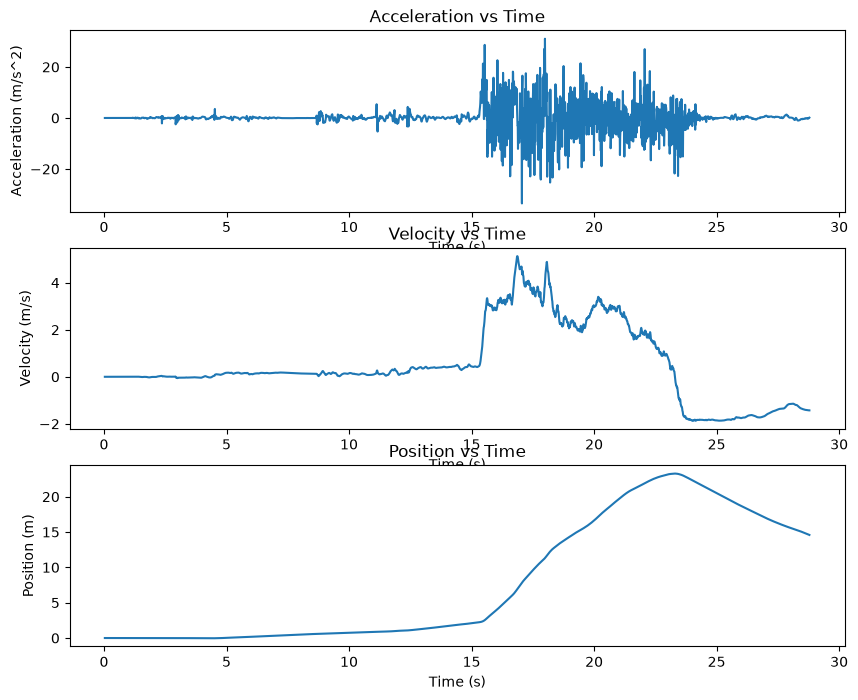

In [ ]:

t = df['Time (s)'].to_numpy()
a = df['Linear Acceleration y (m/s^2)'].to_numpy()

v = cumulative_trapezoid(a, t, initial=0)

x = cumulative_trapezoid(v, t, initial=0)

df['Velocity (m/s)'] = v
df['Position (m)'] = x
df.to_csv("Skateboard Results.csv", index=False)

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(t, a)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration vs Time')

plt.subplot(3, 1, 2)
plt.plot(t, v)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time')

plt.subplot(3, 1, 3)
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs Time')


# # print  ( df['Time (s)'].head(10))